Paquetes necesarios

Podremos hacer uso del mismo *environment* de la primera práctica, aunque en ocasiones pedirá instalar Pillow

In [1]:
import cv2  
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
img = cv2.imread('mandril.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

TAREA: Realiza la cuenta de píxeles blancos por filas (en lugar de por columnas). Determina el valor máximo de píxeles blancos para filas, maxfil, mostrando el número de filas y sus respectivas posiciones, con un número de píxeles blancos mayor o igual que 0.90*maxfil. Resalta con alguna primitiva gráfica en la imagen de Canny las filas que cumplen dicha condición.

(0.0, 512.0)

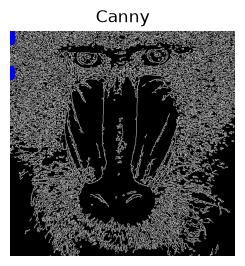

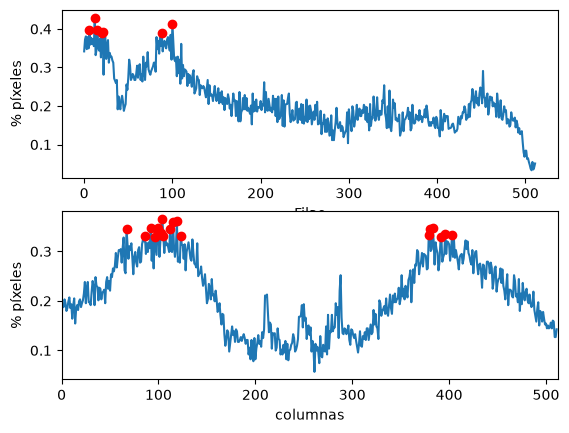

In [2]:
#El contenido de la imagen resultado de Canny, son valores 0 o 255, lo compruebas al descomentar
#print(canny)
#Cuenta el número de píxeles blancos (255) por fila
#Suma los valores de los pixeles por fila


def calculate_maxUmbral(val):
    max_val = np.max(val)
    umbral = max_val * 0.9
    position = np.where(val > umbral)[0]
    return max_val, umbral, position


gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
canny = cv2.Canny(gris, 100, 200)

row_counts = cv2.reduce(canny, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)
col_counts = cv2.reduce(canny, 0, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)


#Normaliza en base al número de filas, primer valor devuelto por shape, y al valor máximo del píxel (255)
#Para poder nromalizarla tenemos que coger todo los valores de la primera dimensión y el primero de la segunda, [fila, fila]
rows_canny = row_counts[:,0] / (255 * canny.shape[1])
max_val_row_canny, umbral_row_canny, position_row_canny = calculate_maxUmbral(rows_canny)

cols_canny = col_counts[0] / (255 * canny.shape[0])
max_val_col_canny, umbral_col_canny, position_col_canny = calculate_maxUmbral(cols_canny)

#Muestra dicha cuenta gráficamente
plt.figure()
plt.subplot(1, 2, 1)
plt.axis("off")
plt.title("Canny")
plt.imshow(canny, cmap='gray') 
plt.plot(np.zeros_like(position_row_canny), position_row_canny, 'bo')  

plt.figure()
plt.subplot(2, 1, 1)
plt.xlabel("Filas")
plt.ylabel("% píxeles")
plt.plot(rows_canny)
plt.plot(position_row_canny, rows_canny[position_row_canny], 'ro')


plt.subplot(2, 1, 2)
plt.xlabel("columnas")
plt.ylabel("% píxeles")
plt.plot(cols_canny)
plt.plot(position_col_canny, cols_canny[position_col_canny], 'ro')



#Rango en x definido por las columnas
plt.xlim([0, canny.shape[1]])

Sobel -> Max Filas: 216.0 | Max Columnas: 219.0
Sobel -> Filas > 90%: [  2   3   4   5   8  11  12  19  20  24  51  80  81  82  83  84  85  87
 100]
Sobel -> Cols > 90%: [104 105 127 288]

Canny -> Max Filas: 220.0 | Max Columnas: 187.0
Canny -> Filas > 90%: [  6  12  15  20  21  88 100]
Canny -> Cols > 90%: [ 67  86  92  96  99 100 103 104 105 112 115 119 123 379 380 383 392 396
 403]


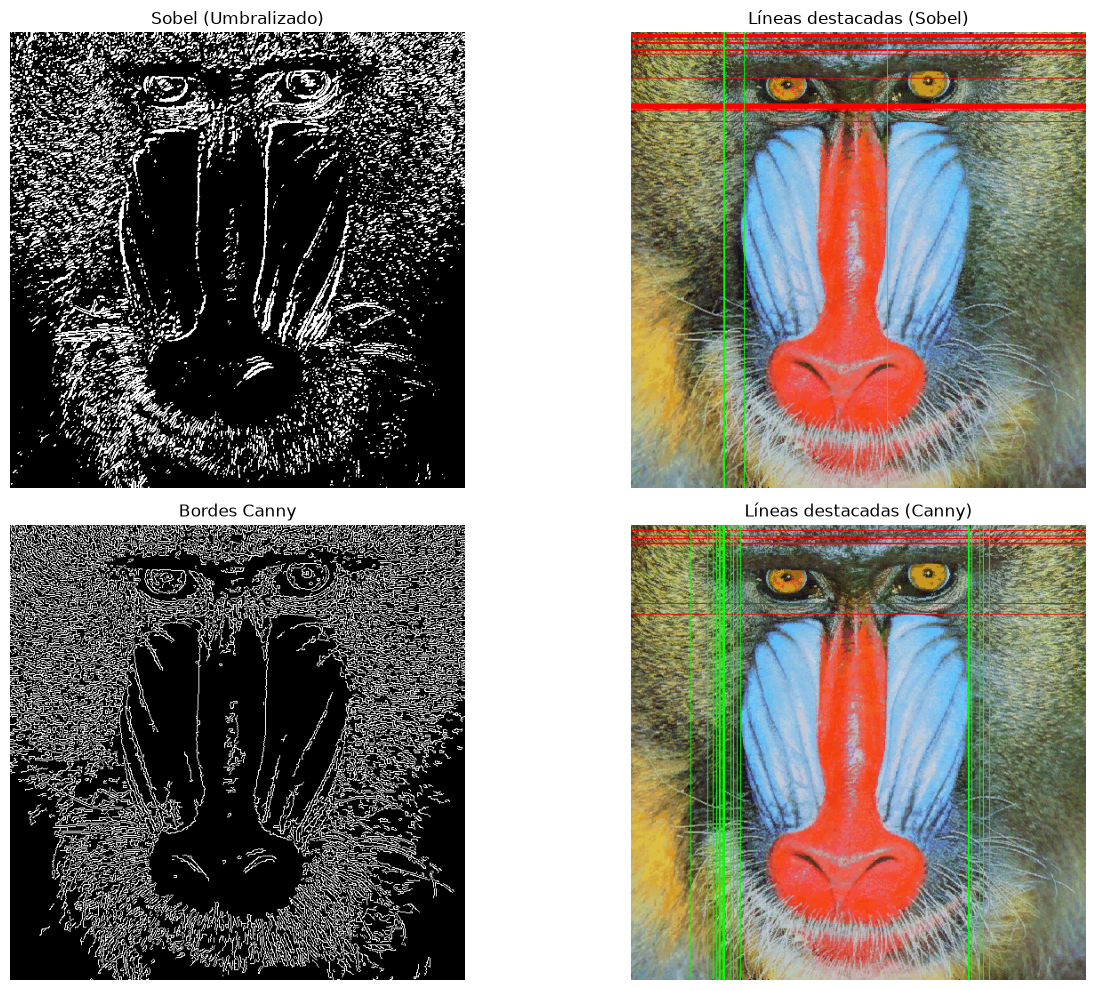

In [ ]:
# 1. Umbralizado de la imagen resultante de Sobel a 8 bits (se asume 'sobel8' generada previamente)
# Elegimos un umbral empírico, por ejemplo 100
_, sobel_thresh = cv2.threshold(sobel8, 100, 255, cv2.THRESH_BINARY)

# 2. Conteo de píxeles no nulos por filas y columnas
# Conteo para Sobel
filas_sobel = cv2.reduce(sobel_thresh, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)[:, 0] / 255
cols_sobel = cv2.reduce(sobel_thresh, 0, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)[0] / 255

# Conteo para Canny (se asume que 'canny' ya está generada en pasos anteriores)
filas_canny = cv2.reduce(canny, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)[:, 0] / 255
cols_canny = cv2.reduce(canny, 0, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)[0] / 255

# 3. Cálculo de máximos y determinación de índices > 0.90 * máximo
max_fila_sobel = np.max(filas_sobel)
max_col_sobel = np.max(cols_sobel)
ind_filas_sobel = np.where(filas_sobel > 0.90 * max_fila_sobel)[0]
ind_cols_sobel = np.where(cols_sobel > 0.90 * max_col_sobel)[0]

max_fila_canny = np.max(filas_canny)
max_col_canny = np.max(cols_canny)
ind_filas_canny = np.where(filas_canny > 0.90 * max_fila_canny)[0]
ind_cols_canny = np.where(cols_canny > 0.90 * max_col_canny)[0]

print(f"Sobel -> Max Filas: {max_fila_sobel} | Max Columnas: {max_col_sobel}")
print(f"Sobel -> Filas > 90%: {ind_filas_sobel}")
print(f"Sobel -> Cols > 90%: {ind_cols_sobel}\n")

print(f"Canny -> Max Filas: {max_fila_canny} | Max Columnas: {max_col_canny}")
print(f"Canny -> Filas > 90%: {ind_filas_canny}")
print(f"Canny -> Cols > 90%: {ind_cols_canny}")

# 4. Remarcado de filas y columnas sobre la imagen original (se asume 'img_rgb')
img_sobel_marcada = img_rgb.copy()
img_canny_marcada = img_rgb.copy()

# Dibujar líneas rojas (filas) y verdes (columnas) para Sobel
for f in ind_filas_sobel:
    cv2.line(img_sobel_marcada, (0, f), (img_sobel_marcada.shape[1], f), (255, 0, 0), 1)
for c in ind_cols_sobel:
    cv2.line(img_sobel_marcada, (c, 0), (c, img_sobel_marcada.shape[0]), (0, 255, 0), 1)

# Dibujar líneas rojas (filas) y verdes (columnas) para Canny
for f in ind_filas_canny:
    cv2.line(img_canny_marcada, (0, f), (img_canny_marcada.shape[1], f), (255, 0, 0), 1)
for c in ind_cols_canny:
    cv2.line(img_canny_marcada, (c, 0), (c, img_canny_marcada.shape[0]), (0, 255, 0), 1)

# 5. Visualización y comparación
plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
plt.title("Sobel (Umbralizado)")
plt.axis("off")
plt.imshow(sobel_thresh, cmap='gray')

plt.subplot(2, 2, 2)
plt.title("Líneas destacadas (Sobel)")
plt.axis("off")
plt.imshow(img_sobel_marcada)

plt.subplot(2, 2, 3)
plt.title("Bordes Canny")
plt.axis("off")
plt.imshow(canny, cmap='gray')

plt.subplot(2, 2, 4)
plt.title("Líneas destacadas (Canny)")
plt.axis("off")
plt.imshow(img_canny_marcada)

plt.tight_layout()
plt.show()

TAREA: Aplica umbralizado a la imagen resultante de Sobel (convertida a 8 bits), y posteriormente realiza el conteo por filas y columnas similar al realizado en el ejemplo con la salida de Canny de píxeles no nulos. Calcula el valor máximo de la cuenta por filas y columnas, y determina las filas y columnas por encima del 0.90*máximo. Remarca con alguna primitiva gráfica dichas filas y columnas sobre la imagen del mandril. Visualiza los resultados obtenidos para la imagen (o una de tu elección) con Canny y Sobe tras umbralizar ¿Cómo se comparan los resultados obtenidos a partir de Sobel y Canny?

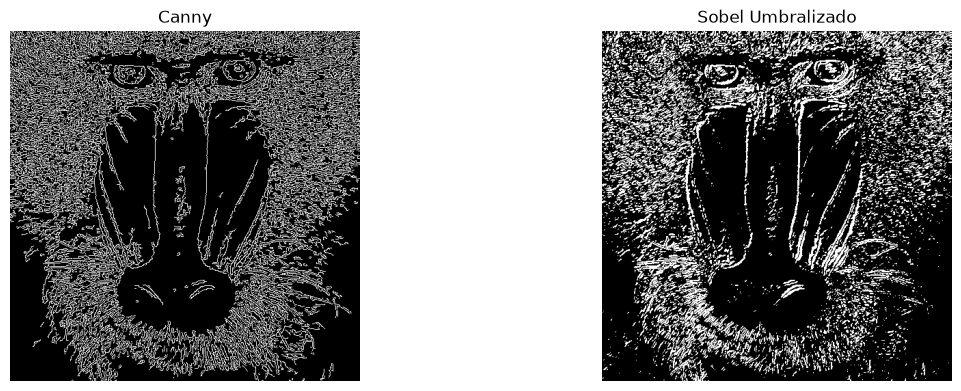

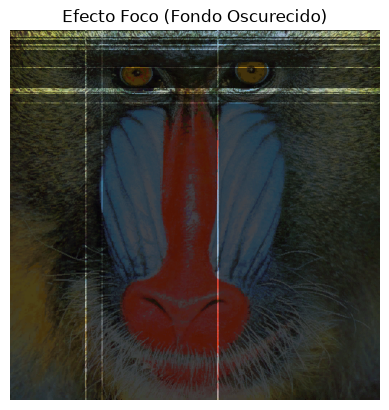

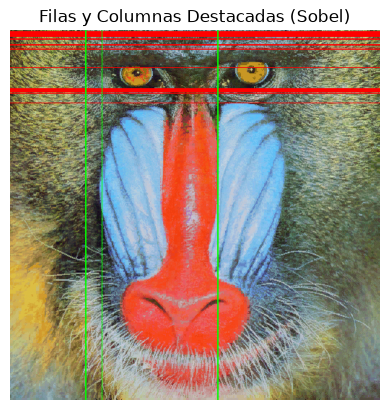

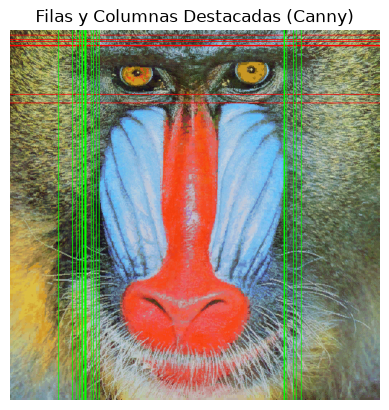

In [33]:
def destacar_filas_columnas(imagen, filas, columnas):
    # Crear una copia de la imagen para no modificar la original
    imagen_destacada = imagen.copy()
    
    # Destacar filas
    for f in filas:
        cv2.line(imagen_destacada, (0, f), (imagen_destacada.shape[1], f), (255, 0, 0), 1)  # Línea roja
    
    # Destacar columnas
    for c in columnas:
        cv2.line(imagen_destacada, (c, 0), (c, imagen_destacada.shape[0]), (0, 255, 0), 1)  # Línea verde
    
    return imagen_destacada
# Imagen de sobel
# Gaussiana para suavizar la imagen original, eliminando altas frecuencias
ggris = cv2.GaussianBlur(gris, (3, 3), 0)

#Calcula en ambas direcciones (horizontal y vertical)
sobelx = cv2.Sobel(ggris, cv2.CV_64F, 1, 0)  # x
sobely = cv2.Sobel(ggris, cv2.CV_64F, 0, 1)  # y
#Combina ambos resultados
sobel = cv2.add(sobelx, sobely)
# Conversión a byte con openCV
sobel8 = cv2.convertScaleAbs(sobel)


valorUmbral = 90 
_, imagenUmbralizada = cv2.threshold(sobel8, valorUmbral, 255, cv2.THRESH_BINARY)

row_count_sobel = cv2.reduce(imagenUmbralizada, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)
col_count_sobel = cv2.reduce(imagenUmbralizada, 0, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)

rows = row_count_sobel[:,0] / (255 * imagenUmbralizada.shape[1])
max_val_sobel, umbral_sobel, position_row_sobel = calculate_maxUmbral(rows)
cols = col_count_sobel[0] / (255 * imagenUmbralizada.shape[0])
max_val_sobel, umbral_sobel, position_col_sobel = calculate_maxUmbral(cols)


plt.figure(figsize=(14, 10))
plt.subplot(2, 2, 1)
plt.axis("off")
plt.title("Canny")
plt.imshow(canny, cmap='gray') 


plt.subplot(2, 2, 2)
plt.axis("off")
plt.title("Sobel Umbralizado")
plt.imshow(imagenUmbralizada, cmap='gray')

plt.show()

img_sobel_marcada = img_rgb.copy()
img_canny_marcada = img_rgb.copy()

# Creamos una versión oscurecida de la imagen original (dividiendo la intensidad)
img_foco = (img_sobel_marcada // 3).astype(np.uint8)

# Restauramos los píxeles originales en las filas seleccionadas
for f in position_row_sobel:
    img_foco[f, :] = img_rgb[f, :]

# Restauramos los píxeles originales en las columnas seleccionadas
for c in position_col_sobel:
    img_foco[:, c] = img_rgb[:, c]

plt.imshow(img_foco)
plt.title("Efecto Foco (Fondo Oscurecido)")
plt.axis("off")
plt.show()

imagen_destacada_sobel = destacar_filas_columnas(img_rgb, position_row_sobel, position_col_sobel)
plt.imshow(imagen_destacada_sobel)
plt.title("Filas y Columnas Destacadas (Sobel)")
plt.axis("off")
plt.show()

imagen_destacada_canny = destacar_filas_columnas(img_rgb, position_row_canny, position_col_canny)
plt.imshow(imagen_destacada_canny)
plt.title("Filas y Columnas Destacadas (Canny)")
plt.axis("off")
plt.show()




TAREA: Tras ver los vídeos [My little piece of privacy](https://www.niklasroy.com/project/88/my-little-piece-of-privacy), [Messa di voce](https://youtu.be/GfoqiyB1ndE?feature=shared) y [Virtual air guitar](https://youtu.be/FIAmyoEpV5c?feature=shared) proponer un demostrador reinterpretando la parte de procesamiento de la imagen, tomando como punto de partida alguna de dichas instalaciones.

In [3]:
# Definimos un pequeño "Sistema de Partículas" para las burbujas
class Burbuja:
    def __init__(self, x, y):
        self.x = x
        self.y = y
        self.vx = random.uniform(-2, 2)
        self.vy = random.uniform(-6, -2) 
        self.radio = random.randint(5, 25) 
        
        # Colores aleatorios estilo neón/burbuja de jabón (Formato BGR en OpenCV)
        self.color = (random.randint(150, 255), random.randint(200, 255), random.randint(200, 255))
        self.vida = 255 # Tiempo de vida antes de explotar/desaparecer

    def actualizar(self):
        # Actualizamos posición
        self.x += self.vx
        self.y += self.vy
        self.vida -= 4 #Envejecimiento de la burbuja
        self.vx += random.uniform(-0.5, 0.5) #Movimiento aleatorio para simular el efecto de flotar



In [ ]:
import cv2
import numpy as np
import random

vid = cv2.VideoCapture(0)
eliminadorFondo = cv2.createBackgroundSubtractorMOG2(history=500, varThreshold=50, detectShadows=False)

# Lista para guardar todas las burbujas activas en la pantalla
lista_burbujas = []

while True:
    ret, frame = vid.read()
    if ret:
        
        frame = cv2.flip(frame, 1)
        objetos = eliminadorFondo.apply(frame)
        
        filas = cv2.reduce(objetos, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)[:, 0]
        cols = cv2.reduce(objetos, 0, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)[0]
        val_max_fila = int(np.max(filas))
        val_max_col = int(np.max(cols))
        umbral = 5000

        if val_max_fila > umbral and val_max_col > umbral:
            max_val, umbral, position_row = calculate_maxUmbral(filas)
            max_val_col, umbral_col, position_col = calculate_maxUmbral(cols)

            num_burbujas = int(max_val / 5000)
            num_burbujas = min(num_burbujas, 4) # Limite

            for x in range(num_burbujas):
                bx = random.randint(0, frame.shape[1])
                by = random.randint(0, frame.shape[0])
                lista_burbujas.append(Burbuja(bx, by))
            
        
        for burbuja in lista_burbujas[:]: # Iteramos sobre una copia de la lista
            burbuja.actualizar() #actualizamos la posición y vida de la burbuja
            # Si la burbuja se sale por arriba o su vida se acaba, la borramos
            if burbuja.vida <= 0 or burbuja.y < 0 or burbuja.x < 0 or burbuja.x > frame.shape[1]:
                lista_burbujas.remove(burbuja)
            else:
                # Dibujar la burbuja (grosor 2 para que sea hueca)
                cv2.circle(frame, (int(burbuja.x), int(burbuja.y)), int(burbuja.radio), burbuja.color, 2)

        cv2.imshow('Generador de Burbujas por Movimiento', frame)

    # Detenemos pulsado ESC
    if cv2.waitKey(20) == 27:
        break

vid.release()
cv2.destroyAllWindows()